# Covariance visualisations for Manuscript V23

This notebook uses the same initial composite kernel as `GPModels_NCDData_Revised.ipynb`.
It generates Supplementary Figures S1 and S2 and main-manuscript Figure 3 from
illustrative input grids. No mortality data are used and no model is fitted here.
These are covariance matrices, not empirical correlation matrices or fitted
covariances shared by all series. Figures are saved in `figures/` as 300-dpi PNGs,
with filenames that match `Supplementary_Material_Revised.tex`.

S1 uses generic kernel parameters. S2 and Figure 3 use the proposed model's
initial parameters. Individual panel colour scales in S2 differ; compare the
colour-bar values rather than colours across panels.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, FileLink

from sklearn.gaussian_process.kernels import (
    Kernel,
    Matern,
    RationalQuadratic,
    RBF,
    WhiteKernel,
)

# Directory for publication-quality PNG figures.
OUTPUT_DIR = Path("figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Settings used only by the forecasting notebook; no optimiser runs here.
RANDOM_STATE = 42
N_RESTARTS_OPTIMIZER = 10
NORMALIZE_Y = False
GPR_ALPHA = 1e-10

# Save PNGs at high resolution while retaining the same figsize/aspect ratios
# used in the original GPKernels_Git notebook.
PNG_DPI = 300


## Exact proposed kernel initialisation

`create_ncd_kernel()` below reproduces the kernel factory used in the revised
forecasting notebook. The explicit White-kernel bounds are included so that the
visualisation notebook and forecasting notebook use the same kernel specification.

The factors \(1.0^2\), \(0.5^2\), and \(0.1^2\) are implemented by scikit-learn as
trainable constant covariance-amplitude terms. They are therefore initial amplitudes,
not fixed weights.

In [2]:
def create_ncd_kernel():
    # Exact proposed composite NCD-kernel initialisation used in revised.
    rq_component = 0.5**2 * RationalQuadratic(
        length_scale=0.7, alpha=0.7
    )
    matern_kernel = 1.0**2 * Matern(length_scale=1.0, nu=1.5)
    rbf_white_component = (
        0.1**2 * RBF(length_scale=0.1)
        + WhiteKernel(
            noise_level=0.1**2,
            noise_level_bounds=(1e-5, 1e5),
        )
    )
    return matern_kernel + rq_component + rbf_white_component


def create_initial_components():
    """Return the three grouped components used in the initial composite kernel."""
    matern_component = 1.0**2 * Matern(length_scale=1.0, nu=1.5)
    rq_component = 0.5**2 * RationalQuadratic(
        length_scale=0.7, alpha=0.7
    )
    rbf_white_component = (
        0.1**2 * RBF(length_scale=0.1)
        + WhiteKernel(
            noise_level=0.1**2,
            noise_level_bounds=(1e-5, 1e5),
        )
    )
    return matern_component, rq_component, rbf_white_component


initial_kernel = create_ncd_kernel()
print("Initial proposed kernel:")
print(initial_kernel)
print("\nNumber of optimisable hyperparameters:", initial_kernel.n_dims)
print("Log-space hyperparameter bounds:")
print(initial_kernel.bounds)

Initial proposed kernel:
1**2 * Matern(length_scale=1, nu=1.5) + 0.5**2 * RationalQuadratic(alpha=0.7, length_scale=0.7) + 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.01)

Number of optimisable hyperparameters: 8
Log-space hyperparameter bounds:
[[-11.51292546  11.51292546]
 [-11.51292546  11.51292546]
 [-11.51292546  11.51292546]
 [-11.51292546  11.51292546]
 [-11.51292546  11.51292546]
 [-11.51292546  11.51292546]
 [-11.51292546  11.51292546]
 [-11.51292546  11.51292546]]


## Supplementary Figure S1: illustrative individual kernel structures

This figure is intentionally **generic**. It illustrates the qualitative covariance
structure of the four kernel families and does not use the complete set of initial
parameters of the proposed NCD composite kernel.

The manuscript should therefore describe Supplementary Figure S1 as showing
*illustrative covariance structures for the individual kernel families*.

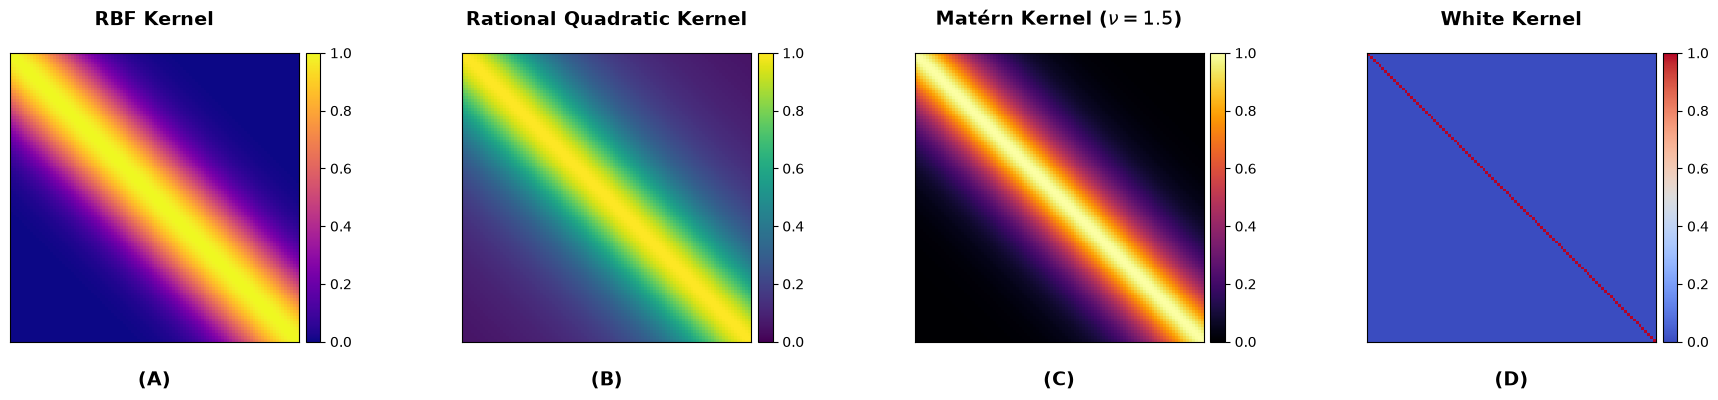

Saved PNG: figures\Figure_S1_Individual_Kernel_Covariances.png
Common colour range: (np.float64(0.0), np.float64(1.0))


C:\Users\wathsala\Documents\NCD\figures\Figure_S1_Individual_Kernel_Covariances.png

In [3]:
def plot_covariance_matrix(
    kernel: Kernel,
    X: np.ndarray,
    ax: plt.Axes,
    title: str,
    cmap: str,
    vmin: float,
    vmax: float,
):
    """Compute and plot the covariance matrix for a given kernel."""
    K = kernel(X)
    cax = ax.matshow(K, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=20)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(cax, ax=ax, shrink=0.75, pad=0.02)
    return K


# Generic illustrative input locations; these are not calendar years.
X_generic = np.linspace(-3, 3, 100).reshape(-1, 1)

# Same four illustrative kernel families and colour maps for this illustration.
generic_kernels = [
    (RBF(length_scale=1.0), "RBF Kernel", "plasma"),
    (
        RationalQuadratic(alpha=1.0, length_scale=1.0),
        "Rational Quadratic Kernel",
        "viridis",
    ),
    (Matern(length_scale=1.0, nu=1.5), "Matérn Kernel ($\\nu=1.5$)", "inferno"),
    (WhiteKernel(noise_level=1.0), "White Kernel", "coolwarm"),
]

# Common numerical colour range, exactly following the original notebook logic.
all_matrices = [kernel(X_generic) for kernel, _, _ in generic_kernels]
all_values = np.concatenate([K.ravel() for K in all_matrices])
vmin_s1, vmax_s1 = all_values.min(), all_values.max()

# Display size used for these illustrations.
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
plt.subplots_adjust(wspace=0.3)

labels = ["(A)", "(B)", "(C)", "(D)"]
for i, (kernel, title, cmap) in enumerate(generic_kernels):
    plot_covariance_matrix(
        kernel, X_generic, axes[i], title, cmap, vmin_s1, vmax_s1
    )
    axes[i].text(
        0.5, -0.1, labels[i],
        transform=axes[i].transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="center",
    )

s1_path = OUTPUT_DIR / "Figure_S1_Individual_Kernel_Covariances.png"
fig.savefig(s1_path, dpi=PNG_DPI, bbox_inches="tight")
plt.show()

print("Saved PNG:", s1_path)
print("Common colour range:", (vmin_s1, vmax_s1))
display(FileLink(str(s1_path), result_html_prefix="Download PNG: "))


## Supplementary Figure S2: grouped components of the initial proposed kernel

Unlike Supplementary Figure S1, the three panels below use the **same initial component
definitions as the proposed composite kernel**:

- Matérn component: \(1.0^2\times\operatorname{Mat\acute{e}rn}(\ell=1.0,\nu=1.5)\)
- Rational Quadratic component:
  \(0.5^2\times\mathrm{RQ}(\ell=0.7,\alpha=0.7)\)
- RBF + White-kernel component:
  \(0.1^2\times\mathrm{RBF}(\ell=0.1)+\mathrm{WhiteKernel}(0.01)\)

The input grid is illustrative and one-dimensional; it is not a set of calendar years
or observed mortality data.

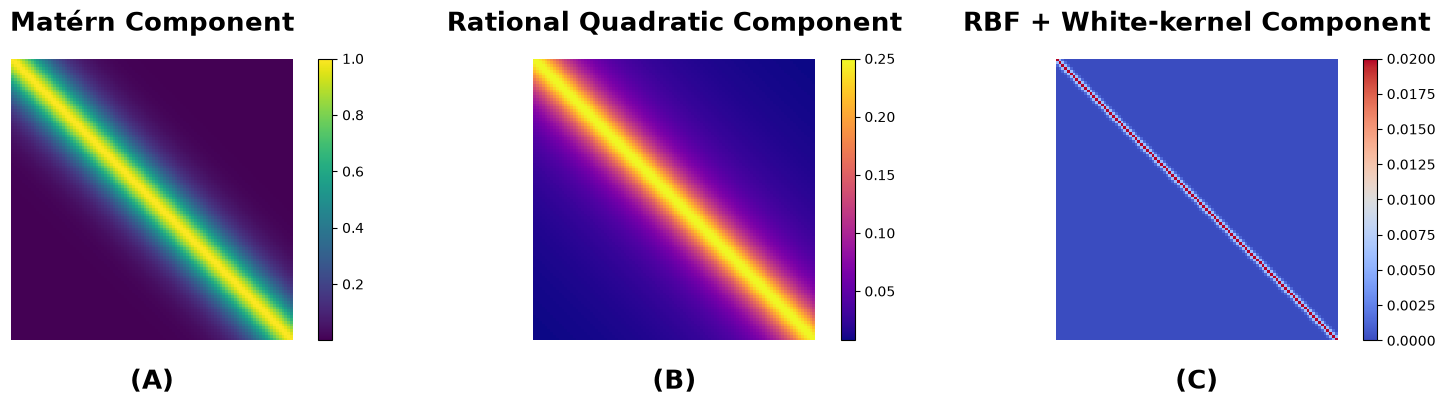

Saved PNG: figures\Figure_S2_Initial_Grouped_Components.png


C:\Users\wathsala\Documents\NCD\figures\Figure_S2_Initial_Grouped_Components.png

In [4]:
# Illustrative one-dimensional input grid used for the initial composite-kernel visualisations.
X_initial = np.linspace(0, 10, 100).reshape(-1, 1)

matern_component, rq_component, rbf_white_component = create_initial_components()

K_matern = matern_component(X_initial)
K_rq = rq_component(X_initial)
K_rbf_white = rbf_white_component(X_initial)

# Display size and plotting arrangement used for these illustrations.
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True)

labels = ["(A)", "(B)", "(C)"]

# Same colour maps for these illustrations, with revised scientific terminology.
im_matern = axes[0].imshow(
    K_matern, cmap="viridis", interpolation="nearest"
)
axes[0].set_title(
    "Matérn Component", fontweight="bold", fontsize=19, pad=20
)
axes[0].axis("off")
axes[0].text(
    0.5, -0.1, labels[0],
    transform=axes[0].transAxes,
    fontsize=19,
    fontweight="bold",
    va="top",
    ha="center",
)

im_rq = axes[1].imshow(
    K_rq, cmap="plasma", interpolation="nearest"
)
axes[1].set_title(
    "Rational Quadratic Component", fontweight="bold", fontsize=19, pad=20
)
axes[1].axis("off")
axes[1].text(
    0.5, -0.1, labels[1],
    transform=axes[1].transAxes,
    fontsize=19,
    fontweight="bold",
    va="top",
    ha="center",
)

im_rbf_white = axes[2].imshow(
    K_rbf_white, cmap="coolwarm", interpolation="nearest"
)
axes[2].set_title(
    "RBF + White-kernel Component", fontweight="bold", fontsize=19, pad=20
)
axes[2].axis("off")
axes[2].text(
    0.5, -0.1, labels[2],
    transform=axes[2].transAxes,
    fontsize=19,
    fontweight="bold",
    va="top",
    ha="center",
)

# Same colourbar arrangement for these illustrations.
fig.colorbar(im_matern, ax=axes[0], orientation="vertical")
fig.colorbar(im_rq, ax=axes[1], orientation="vertical")
fig.colorbar(im_rbf_white, ax=axes[2], orientation="vertical")

plt.tight_layout()

s2_path = OUTPUT_DIR / "Figure_S2_Initial_Grouped_Components.png"
fig.savefig(s2_path, dpi=PNG_DPI, bbox_inches="tight")
plt.show()

print("Saved PNG:", s2_path)
display(FileLink(str(s2_path), result_html_prefix="Download PNG: "))


## Figure 3: covariance matrix of the initial composite NCD kernel

This is the covariance matrix of the **initial** composite kernel, before any
mortality-series-specific hyperparameter optimisation. It is therefore a prior covariance
visualisation, not an empirical correlation matrix and not a single fitted covariance
matrix shared by all country--disease--sex series.

In the revised forecasting notebook, each training series is standardised and fitted
separately, and eligible hyperparameters are optimised with
`n_restarts_optimizer=10`, `random_state=42`, and `normalize_y=False`.

Maximum |composite - sum(components)|: 0.0


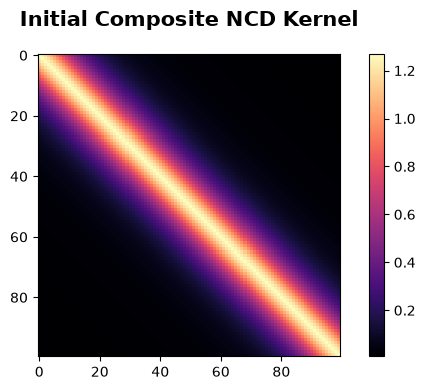

Saved PNG: figures\Figure_3_Initial_Composite_NCD_Kernel.png
Covariance range: (np.float64(0.00760886623084004), np.float64(1.27))


C:\Users\wathsala\Documents\NCD\figures\Figure_3_Initial_Composite_NCD_Kernel.png

In [5]:
initial_composite_kernel = create_ncd_kernel()
K_initial_composite = initial_composite_kernel(X_initial)

# Numerical verification: composite covariance equals sum of grouped components.
K_component_sum = K_matern + K_rq + K_rbf_white
max_abs_difference = np.max(np.abs(K_initial_composite - K_component_sum))
assert np.allclose(K_initial_composite, K_component_sum)
print("Maximum |composite - sum(components)|:", max_abs_difference)

# Display size and colour map used for these illustrations.
fig, ax = plt.subplots(figsize=(6, 4))
im_ncd = ax.imshow(
    K_initial_composite,
    cmap="magma",
    interpolation="nearest",
)
ax.set_title(
    "Initial Composite NCD Kernel",
    fontweight="bold",
    fontsize=15,
    pad=20,
)

# Same colourbar placement for these illustrations.
fig.colorbar(im_ncd, ax=ax, orientation="vertical")

plt.tight_layout()

fig3_path = OUTPUT_DIR / "Figure_3_Initial_Composite_NCD_Kernel.png"
fig.savefig(fig3_path, dpi=PNG_DPI, bbox_inches="tight")
plt.show()

print("Saved PNG:", fig3_path)
print(
    "Covariance range:",
    (K_initial_composite.min(), K_initial_composite.max()),
)
display(FileLink(str(fig3_path), result_html_prefix="Download PNG: "))


## Reproducibility note

This visualisation notebook and the revised forecasting notebook now use the same
initial proposed composite-kernel specification.

The forecasting notebook performs additional operations that are intentionally absent
here:

1. calendar year and mortality rate are standardised using each training set only;
2. the composite kernel is passed to `GaussianProcessRegressor`;
3. eligible hyperparameters are optimised by maximising log marginal likelihood;
4. optimisation uses 10 additional random restarts after the initial optimisation;
5. `random_state=42` and `normalize_y=False` are used; and
6. the fitted covariance structure can therefore differ between
   country--disease--sex time series.

Accordingly, the covariance figures generated here should be described as illustrations
of the **initial** kernel structure.

In [6]:
print("All generated PNG figures:")
for png_file in [
    OUTPUT_DIR / "Figure_S1_Individual_Kernel_Covariances.png",
    OUTPUT_DIR / "Figure_S2_Initial_Grouped_Components.png",
    OUTPUT_DIR / "Figure_3_Initial_Composite_NCD_Kernel.png",
]:
    if png_file.exists():
        display(FileLink(str(png_file), result_html_prefix="Download: "))
    else:
        print("Run the figure cells first:", png_file)


All generated PNG figures:


C:\Users\wathsala\Documents\NCD\figures\Figure_S1_Individual_Kernel_Covariances.png

C:\Users\wathsala\Documents\NCD\figures\Figure_S2_Initial_Grouped_Components.png

C:\Users\wathsala\Documents\NCD\figures\Figure_3_Initial_Composite_NCD_Kernel.png